In [1]:
# General notebook settings
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
my_colour = ["r", "g", "b", "m", "c", "y"]
import numpy as np

In [2]:
from samples import samples
demomec = samples.CH82()
conc = 100e-9    # 100 nM
demomec.set_eff('c', conc)
tres = 0.0001  # resolution in seconds

Display open time adjacent to shut time range pdf:

In [3]:
u1, u2 = 0.1e-3, 1e-3 # 1 ms, 10 ms

from scalcs.adjacent import AdjacentPDFDisplay
pdf_adjacent = AdjacentPDFDisplay(demomec, tres=tres)
print(pdf_adjacent.ideal_adjacent_dwells(u1, u2))


PDF of open times that precede shut times between 0.100 and 1.000 ms

OPEN TIMES ADJACENT TO SPECIFIED SHUT TIME RANGE
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |   Area (%) |
|--------+-------------+----------------+------------+------------|
|      1 |    494.604  |        500.654 |   1.99739  |   98.7916  |
|      2 |     36.8556 |       3050.01  |   0.327867 |    1.20838 |
Mean (ms) = 1.9772		SD = 1.994		SD/mean = 1.0085
Mean from direct calculation (ms) = 1.977215



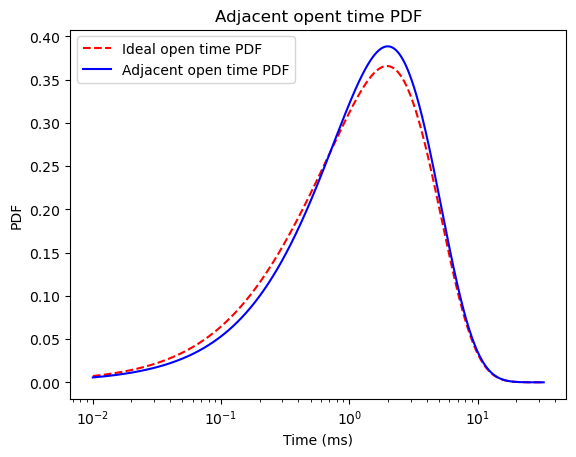

In [4]:
pdf_adjacent.plot_adjacent_open_time_pdf(tres, u1, u2)

Mean open time preceding specified shut time- red dashed line.
Mean open time next to specified shut time- blue dashed line.


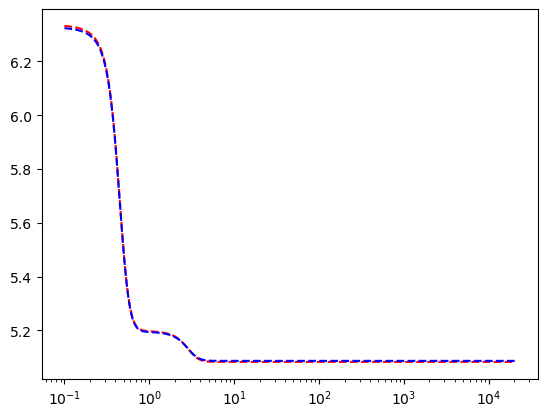

In [5]:
from scalcs.adjacent import mean_open_next_shut
sht, mp, mn = mean_open_next_shut(demomec, tres)
plt.semilogx(sht, mp, 'r--', sht, mn, 'b--')
print('Mean open time preceding specified shut time- red dashed line.\n' +
'Mean open time next to specified shut time- blue dashed line.')

Display dependency plot:

In [6]:
from scalcs.adjacent import dependency_plot
to, ts, d = dependency_plot(demomec, tres, points=128)
fig = plt.figure()
fig.suptitle('Dependency plot', fontsize=12)
ax = fig.gca(projection='3d')
to, ts = np.meshgrid(to, ts)
surf = ax.plot_surface(to, ts, d, rstride=1, cstride=1, cmap=cm.coolwarm,
    linewidth=0, antialiased=False)
ax.set_zlim(-1.0, 1.0)

TypeError: FigureBase.gca() got an unexpected keyword argument 'projection'

<Figure size 640x480 with 0 Axes>